# Demo — fine-tuning PARNET on spliceosome data (HepG2)

## Set-up

### Imports

In [ ]:
import pylbsr.notebooks
import pylbsr.misc
import functools
import torch
import torch.utils.data
import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger
from dotmap import DotMap
from pathlib import Path
import yaml
from typing import Literal

import parnet
from parnet.layers import (
    AdditiveMix,
    LinearProjectionHead,
    MixCoeffMLP,
    MixCoeffPenalty,
    NewAdditiveMix,
    LinearProjection,
    NewMixCoeffMLP,
    NewMixCoeffPenalty,
)
from parnet.losses import MultinomialNLLLoss
from parnet.bin.train import LightningModel
from parnet.data.datasets import ListDataset
from parnet_additional_utils import (
    load_parnet_model,
    load_parnet_model_from_statedict,
    ParnetModelName,
    save_parnet_model_as_statedict,
)
from parnet.utils import count_trainable_params

/home/l10n/projects/parnet-project/parnet--demo--train-models/.pixi/envs/parnet-dev-cu11/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42
/home/l10n/projects/parnet-project/parnet--demo--train-models/.pixi/envs/parnet-dev-cu11/lib/python3.10/site-packages/parnet/constants.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

### Initialization

In [14]:
pylbsr.misc.set_seed(42)

torch.use_deterministic_algorithms(
    False
)  # some backbone ops (dilated convs) have no deterministic CUDA kernel

device = torch.device("cuda:1")
torch.cuda.set_device(1)

# ===

_notebook_name = "train_from_pretrained.py.ipynb"
_notebook_path = f"notebooks/demo--train-spliceosome-hepg2/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)

logger = pylbsr.misc.init_logger(_notebook_name)

PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[11:06:24] INFO - Project directory: /home/l10n/projects/parnet-project/parnet--demo--train-models
INFO:train_from_pretrained.py.ipynb:Project directory: /home/l10n/projects/parnet-project/parnet--demo--train-models


Seed set to 42
⏱ 0.00 s (00:00:00)


### Parameters

In [15]:
# ── Task / data configuration ──────────────────────────────────────────────────
params_num_tasks = 9  # number of spliceosome RBPs selected in prepare_datasets
params_seq_length = 600  # center-cropped window length (from prepare_datasets)

# ── Training strategy ─────────────────────────────────────────────

# We start from a specific pretrained parnet model so as to speed-up the training process.
pretrained_model_name = ParnetModelName.PARNET_7M_0_0

# Which head architecture to attach after resetting the pretrained head (see section below).
# Options:
#   "additive_mix"     — AdditiveMix, standard logsumexp (use_maximum_target_control_logprob=False)
#   "additive_mix_max" — AdditiveMix, max-stabilised logprob (use_maximum_target_control_logprob=True)
#                        RECOMMENDED: consistent with 7M / 21M pretrained training settings
#   "new_additive_mix" — NewAdditiveMix (experimental; control_nograd not functional in forward)
params_head_variant: Literal["additive_mix", "additive_mix_max", "new_additive_mix"] = (
    "additive_mix_max"
)

# Which finetuning strategy to use:
# - "full": finetune all parameters of the model
# - "head": only finetune the parameters of the projection head (i.e.
# - "unfreeze_last_n_layers": only finetune the parameters of the projection head + the last n layers of the backbone
params_finetuning_strategy: Literal["full", "head", "unfreeze_last_n_layers"] = "head"

# Below: only used if `params_finetuning_strategy == "unfreeze_last_n_layers"`
params_unfreeze_last_layers_n = 2

# ── Penalty parameter ──────────────────────────────────────────────────────────
# Controls mixing-coefficient regularisation (explained in detail below).
params_penalty_factor = 5.0

# ── Training hyperparameters ───────────────────────────────────────────────────
params_batch_size = 32
params_max_epochs = 5
params_lr = 1e-4

# Name to save the resulting model under (in output_dir)
# ------------------------------------------------------
# TODO: manually updated by the user ; this should encompass the different
params_name_of_resulting_model = "parnet.7m-0.0.ft-head.spliceosome-hepg2"


⏱ 0.00 s (00:00:00)


### Filepaths

In [ ]:
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())


def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p


FILEPATHS = DotMap()
FILEPATHS["filtered_dataset"] = (
    PROJECT_DIR / "results" / "spliceosome-hepg2" / "datasets" / "dataset.pt"
)
FILEPATHS["pretrained_model"] = _res(_fp_cfg["models"][pretrained_model_name.value])
FILEPATHS["output_dir"] = PROJECT_DIR / "results" / "spliceosome-hepg2" / "training"

## Load filtered dataset

In [17]:
# Load metadata written by prepare_datasets to confirm what was saved
saved_meta = torch.load(FILEPATHS["filtered_dataset"])["metadata"]
logger.info(f"Dataset RBPs ({saved_meta['num_tasks']}): {saved_meta['rbp_cts']}")
logger.info(f"Cropped sequence length: {saved_meta['crop_end'] - saved_meta['crop_start']} nt")

# IMPORTANT: pass length=params_seq_length (600) to ListDataset.
# Without it, the default length=2000 would pad every 600 nt sequence back to 2000 nt.
train_ds = ListDataset(
    FILEPATHS["filtered_dataset"], split="train", length=params_seq_length, shuffle=True
)
val_ds = ListDataset(
    FILEPATHS["filtered_dataset"], split="valid", length=params_seq_length, shuffle=False
)
logger.info(f"\nDataset sizes — train: {len(train_ds)}, val: {len(val_ds)}")

# Inspect one sample (ListDataset renames 'eCLIP' → 'total' for compatibility with LightningModel)
sample = train_ds[0]
print("\nInput  sequence shape:", sample["inputs"]["sequence"].shape)
for task, tensor in sample["outputs"].items():
    print(f"Output '{task}' shape  :", tensor.shape)

/tmp/ipykernel_312779/3209735462.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_meta = torch.load(FILEPATHS["filtered_dataset"])["metadata"]
[11:06:37] INFO - Dat


Input  sequence shape: torch.Size([4, 600])
Output 'total' shape  : torch.Size([9, 600])
Output 'control' shape  : torch.Size([9, 600])
⏱ 15.08 s (00:00:15)


## Load pretrained model and reset head

In [18]:
# load_parnet_model applies model-specific post-load settings (from PARNET_MODEL_CONFIGS):
#   • model.projection = lambda x: x   (bypasses the embedding-dim projection)
#   • model.head.use_maximum_target_control_logprob = True / False
model = load_parnet_model(
    pretrained_model_name,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)
logger.info(f"Loaded pretrained model — trainable params: {count_trainable_params(model):,}")
_head_conv = getattr(model.head.head_target, "pointwise", None) or getattr(
    model.head.head_target, "pointwise_conv", None
)
logger.info(f"Pretrained head num_tasks: {_head_conv.out_channels}")

/home/l10n/projects/parnet-project/parnet_additional_utils/src/parnet_additional_utils/utils.py:254: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model: RBPNet = torch.load

⏱ 0.27 s (00:00:00)


## Head architecture

The parnet library (`dev` branch) provides two mixing-head classes.
Select one via `params_head_variant` in the parameters cell.

### Comparison

| | `additive_mix` | `additive_mix_max` ✓ | `new_additive_mix` |
| --- | --- | --- | --- |
| Class | `AdditiveMix` | `AdditiveMix` | `NewAdditiveMix` |
| Projection layer | `LinearProjectionHead` | same | `LinearProjection` |
| Mix-coeff layer | `MixCoeffMLP` | same | `NewMixCoeffMLP` |
| Penalty layer | `MixCoeffPenalty` | same | `NewMixCoeffPenalty` |
| Logprob formula | logsumexp | max-stabilised | max-stabilised (fixed) |
| NaN/Inf validation | yes | yes | no |
| `control_nograd` | functional | functional | stored but unused (bug) |
| Recommended for | baseline | **7M/21M fine-tuning** | experimental |

**`MixCoeffMLP` vs `NewMixCoeffMLP`**: both are a 2-layer MLP that spatially
mean-pools the backbone embedding `(B, D, L) → (B, D)`, passes it through two
`LazyLinear` layers (hidden size 128), and outputs a sigmoid mixing coefficient
`(B, num_tasks)`. The `New` variant is a separate class only for gin-config isolation;
the logic is identical. The same equivalence holds for `MixCoeffPenalty` vs
`NewMixCoeffPenalty` (both: `factor=1.0` by default, no other arguments).

**`use_maximum_target_control_logprob`** (`AdditiveMix` only): controls how the target
and control log-probabilities are combined. `False` uses
`logsumexp([α + log p_t,  log p_c])`; `True` uses the numerically equivalent but
more stable formula `max + log(α·exp(p_t − max) + (1−α)·exp(p_c − max))`.
The 7M and 21M pretrained models were trained with `True`, so `additive_mix_max`
is the natural choice when fine-tuning from them.

**Penalty API difference**: `AdditiveMix` expects `penalty_layer` as a *class* and
calls `penalty_layer()` internally; `NewAdditiveMix` expects a pre-instantiated
*object*. The cell below handles this transparently.

In [19]:
# The pretrained head has 223 output tasks (one per eCLIP experiment).
# We replace it with a fresh head for our params_num_tasks spliceosome tasks.
# The backbone (stem + body) keeps its pretrained weights throughout.

if params_head_variant == "additive_mix":
    model.head = AdditiveMix(
        num_tasks=params_num_tasks,
        head_layer=LinearProjectionHead,
        mix_coeff_layer=MixCoeffMLP,
        # MixCoeffPenalty is a class; AdditiveMix instantiates it internally via penalty_layer()
        penalty_layer=MixCoeffPenalty,
        use_maximum_target_control_logprob=False,
    )
elif params_head_variant == "additive_mix_max":
    model.head = AdditiveMix(
        num_tasks=params_num_tasks,
        head_layer=LinearProjectionHead,
        mix_coeff_layer=MixCoeffMLP,
        penalty_layer=MixCoeffPenalty,
        # max-stabilised logprob; consistent with 7M / 21M pretrained training
        use_maximum_target_control_logprob=True,
    )
elif params_head_variant == "new_additive_mix":
    model.head = NewAdditiveMix(
        num_tasks=params_num_tasks,
        head_layer=LinearProjection,
        mix_coeff_layer=NewMixCoeffMLP,
        # NewMixCoeffPenalty must be pre-instantiated; NewAdditiveMix stores it directly
        penalty_layer=NewMixCoeffPenalty(),
    )
else:
    raise ValueError(f"Unknown head variant: {params_head_variant!r}")

model.head.penalty.factor = params_penalty_factor
model = model.to(device)

# LazyConv1d and LazyLinear layers need one forward pass to initialise their weights.
with torch.no_grad():
    _ = model(torch.zeros(1, 4, params_seq_length, dtype=torch.float32, device=device))

logger.info(f"New head ({params_head_variant}): {model.head}")
logger.info(f"Trainable params after head reset: {count_trainable_params(model):,}")

[11:07:06] INFO - New head (additive_mix_max): AdditiveMix(
  (head_target): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (head_control): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (mix_coeff): MixCoeffMLP(
    (dense1): Linear(in_features=512, out_features=128, bias=True)
    (act): ReLU()
    (dense2): Linear(in_features=128, out_features=9, bias=True)
  )
  (penalty): MixCoeffPenalty()
)
INFO:train_from_pretrained.py.ipynb:New head (additive_mix_max): AdditiveMix(
  (head_target): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (head_control): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (mix_coeff): MixCoeffMLP(
    (dense1): Linear(in_features=512, out_features=128, bias=True)
    (act): ReLU()
    

⏱ 0.02 s (00:00:00)


### Inspect the head structure

The class names of the head sub-layers are stored in the state-dict bundle by
`save_parnet_model_as_statedict` and resolved back by `load_parnet_model_from_statedict`
(via `_resolve_parnet_layer_cls`). Run the cell below to confirm the class names match
what you expect — useful when debugging save/load across parnet versions.

In [20]:
# 1. Full head module tree (layer types and shapes after lazy init)
print(model.head)
print()

# 2. Class names stored in the statedict bundle on save
print("head_layer      :", type(model.head.head_target).__name__)
print("mix_coeff_layer :", type(model.head.mix_coeff).__name__)
print("penalty_layer   :", type(model.head.penalty).__name__ if model.head.penalty else None)
print()

# 3. All named submodules — mirrors what load_parnet_model_from_statedict resolves
for name, module in model.head.named_modules():
    if name:
        print(f"  {name:30s}  {type(module).__name__}")

AdditiveMix(
  (head_target): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (head_control): LinearProjectionHead(
    (pointwise): Conv1d(512, 9, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
  (mix_coeff): MixCoeffMLP(
    (dense1): Linear(in_features=512, out_features=128, bias=True)
    (act): ReLU()
    (dense2): Linear(in_features=128, out_features=9, bias=True)
  )
  (penalty): MixCoeffPenalty()
)

head_layer      : LinearProjectionHead
mix_coeff_layer : MixCoeffMLP
penalty_layer   : MixCoeffPenalty

  head_target                     LinearProjectionHead
  head_target.pointwise           Conv1d
  head_control                    LinearProjectionHead
  head_control.pointwise          Conv1d
  mix_coeff                       MixCoeffMLP
  mix_coeff.dense1                Linear
  mix_coeff.act                   ReLU
  mix_coeff.dense2                Linear
  penalty                         MixCoeffP

## The penalty parameter

`AdditiveMix` combines a *target* (eCLIP) track and a *control* track using a per-task mixing coefficient α ∈ [0, 1]:

$$\text{total\_log\_prob} = \log\!\left[\alpha \cdot e^{\text{target}} + (1-\alpha)\cdot e^{\text{control}}\right]$$

`MixCoeffPenalty` adds an explicit regularisation term to the loss:

$$\mathcal{L} = \mathcal{L}_\text{eCLIP} + \mathcal{L}_\text{control} + \underbrace{\texttt{penalty\_factor} \times \overline{\alpha}}_{\text{penalty}}$$

A **higher penalty_factor** pushes α toward 0, meaning the model relies more on the control track — which captures sequence-level biases unrelated to RBP binding. This can improve calibration and reduce false positives caused by sequence bias.

| `params_penalty_factor` | Effect |
|---|---|
| `0.0` | No regularisation; model free to fully trust eCLIP signal |
| `>0.0` | Gentle pressure to reduce mixing coefficients |
| `>10.0` | May underfit if dataset is small |

The default here is `params_penalty_factor = 0.0`.

Re-run this notebook with `5.0` or `20.0` to compare the effect on validation loss and mixing coefficient distribution (`val/mix_coeff`).

## Freezing strategy

Set `params_finetuning_strategy` in the Parameters cell to one of three options:

| Value | What is trained | When to use |
|---|---|---|
| `"head"` | New head only (stem + body frozen) | Fast warm-up; source and target domains are similar |
| `"unfreeze_last_n_layers"` | Head + last `params_unfreeze_last_layers_n` body blocks | Middle ground; partial backbone adaptation |
| `"full"` | All parameters | Target domain differs from pretraining, or dataset is large |

A common recipe: first run `"head"` for a few epochs to stabilise the head, then switch to `"full"` with a lower learning rate.

In [21]:
if params_finetuning_strategy == "head":
    for param in model.stem.parameters():
        param.requires_grad = False
    for param in model.body.parameters():
        param.requires_grad = False
    print(f"[head] Trainable params: {count_trainable_params(model):,}  (head only)")

elif params_finetuning_strategy == "unfreeze_last_n_layers":
    for param in model.parameters():
        param.requires_grad = False
    body_blocks = list(model.body.children())
    for block in body_blocks[-params_unfreeze_last_layers_n:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in model.head.parameters():
        param.requires_grad = True
    print(
        f"[unfreeze_last_{params_unfreeze_last_layers_n}_layers] "
        f"Trainable params: {count_trainable_params(model):,}"
    )

elif params_finetuning_strategy == "full":
    for param in model.parameters():
        param.requires_grad = True
    print(f"[full] Trainable params: {count_trainable_params(model):,}  (all layers)")

else:
    raise ValueError(f"Unknown finetuning strategy: {params_finetuning_strategy!r}")

[head] Trainable params: 76,041  (head only)
⏱ 0.00 s (00:00:00)


## Training

In [24]:
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)

optimizer_cls = functools.partial(torch.optim.AdamW, lr=params_lr)
lightning_model = LightningModel(
    model=model,
    loss_fn=MultinomialNLLLoss(),
    optimizer=optimizer_cls,
    use_control=True,
)


# ── In-memory metric collection (Option B) ────────────────────────────────────
# Snapshots all callback_metrics at the end of every epoch for post-training plots.
class MetricHistory(pl.Callback):
    def __init__(self):
        self.history = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.history.append({k: float(v) for k, v in trainer.callback_metrics.items()})


metric_history = MetricHistory()

# ── Loggers ───────────────────────────────────────────────────────────────────
# CSVLogger  → FILEPATHS["output_dir"] / "csv_logs"  / version_N / metrics.csv
# TBLogger   → FILEPATHS["output_dir"] / "tensorboard_logs" / version_N /
csv_logger = CSVLogger(save_dir=FILEPATHS["output_dir"], name="csv_logs")
tb_logger = TensorBoardLogger(save_dir=FILEPATHS["output_dir"], name="tensorboard_logs")

FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
trainer = pl.Trainer(
    default_root_dir=FILEPATHS["output_dir"],
    max_epochs=params_max_epochs,
    accelerator="gpu",
    devices=[1],
    logger=[csv_logger, tb_logger],
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=FILEPATHS["output_dir"] / "checkpoints",
            monitor="val/loss",
            mode="min",
            filename="best",
            save_last=True,
            save_top_k=1,
        ),
        metric_history,
    ],
)

trainer.fit(lightning_model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/l10n/projects/parnet-project/parnet--demo--train-models/.pixi/envs/parnet-dev-cu11/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/l10n/projects/parnet-project/parnet--demo--train-models/results/spliceosome-hepg2/training/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name                 | Type               | Params | Mode 
--------------------------------------------------------------------
0 | model                | RBPNet             | 7.2 M  | train
1 | loss_fn              | MultinomialNLLLoss | 0      | train
2 | penalty_loss         | MeanMetric         | 0      | train
3 | train_metrics_losses | MetricCollection   | 0      | train
4 | train_metrics_eCLIP  | MetricCollection   | 0      | train
5 | train_metrics_SMI    | MetricCollection   | 0      | train
6 | val_metrics_losses   | MetricCollec

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/l10n/projects/parnet-project/parnet--demo--train-models/.pixi/envs/parnet-dev-cu11/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:527: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


⏱ 2150.03 s (00:35:50)


### Monitoring training metrics

Three complementary options — all active after every `trainer.fit()` run:

| Option | How | When to use |
| --- | --- | --- |
| **B** (cell below) | In-memory `MetricHistory` callback → matplotlib | Quick post-training plot; lost on kernel restart |
| **C** (second cell) | TensorBoard in-notebook (`%tensorboard`) | Interactive, real-time monitoring during training |
| **A** (in "Quick sanity check" section) | Read `metrics.csv` written by `CSVLogger` | Survives kernel restarts; compare multiple runs |

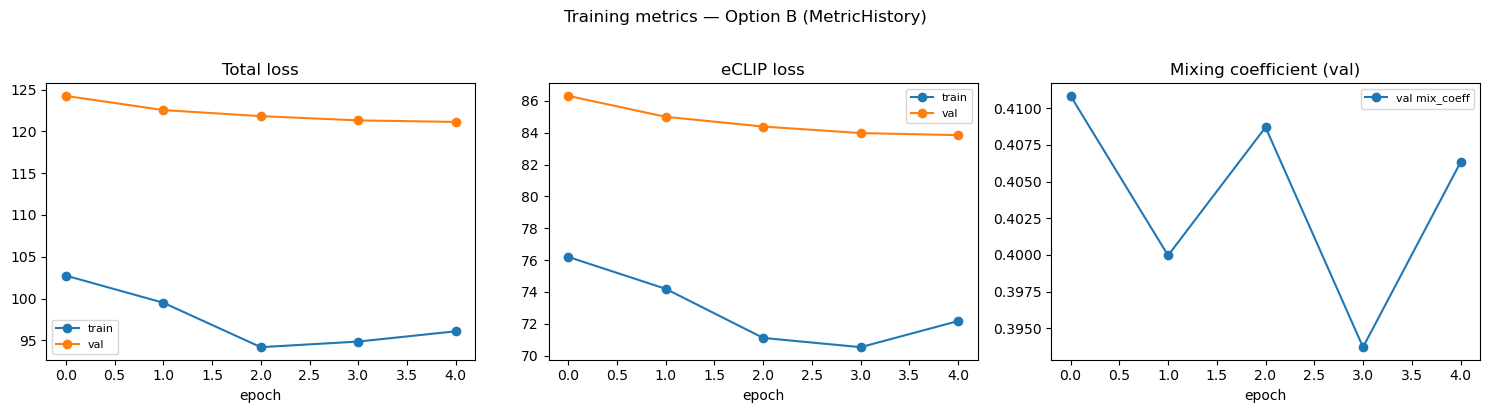

⏱ 0.23 s (00:00:00)


In [25]:
# Option B — in-memory loss curves from MetricHistory callback
# Available immediately after trainer.fit(); lost if kernel restarts.
import pandas as pd
import matplotlib.pyplot as plt

df_b = pd.DataFrame(metric_history.history)
df_b["epoch"] = range(len(df_b))

# train/* metrics have _epoch suffix (logged on_step+on_epoch → Lightning disambiguates)
# val/*   metrics have no suffix (logged on_epoch only)
plots = [
    ({"train": "train/loss_epoch", "val": "val/loss"}, "Total loss"),
    ({"train": "train/loss_eCLIP_epoch", "val": "val/loss_eCLIP"}, "eCLIP loss"),
    ({"val mix_coeff": "val/mix_coeff"}, "Mixing coefficient (val)"),
]

fig, axes = plt.subplots(1, len(plots), figsize=(15, 4))
for (col_dict, title), ax in zip(plots, axes):
    for label, col in col_dict.items():
        if col in df_b.columns:
            df_b.plot("epoch", col, ax=ax, label=label, marker="o")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Training metrics — Option B (MetricHistory)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Option C — TensorBoard in-notebook
# TensorBoard 2.16 is already installed (via the tensorflow dependency in the pixi env).
# The TensorBoardLogger above writes event files to:
#   FILEPATHS["output_dir"] / "tensorboard_logs" / version_N /
# Run this cell at any point — before, during, or after training — to open the dashboard.

# NOTE: if using VSCode through SSH on a remote machine: VSCode will silently run `ssh -L LOCAL_PORT:localhost:6006 remote`
# and should open a notification offering to open the dashboard in a browser tab.
# If not, you can manually navigate to http://localhost:PORT/ after running this cell (considering the port printed here by tensorboard.)
# Check `lsof -i :{PORT}` in a terminal on the remote machine to see if the tensorboard process is indeed running and listening on that port.
# Check `curl localhost:{PORT}` in a terminal on the remote machine to see if you get a response from the tensorboard server.

%load_ext tensorboard
_tb_logdir = str(FILEPATHS["output_dir"] / "tensorboard_logs")
%tensorboard --logdir {_tb_logdir}

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 313011), started 0:42:32 ago. (Use '!kill 313011' to kill it.)

⏱ 0.01 s (00:00:00)


#### NOTE: TensorBoard with the parnet training scripts

When using parnet's standalone `train()` function via a gin config file (as opposed to this
notebook), pass `TensorBoardLogger` through the `loggers` gin binding:

```gin
# in your .gin config file
train.loggers = [@TensorBoardLogger]
```

The `_make_loggers` helper in `parnet.bin.train` will instantiate it with
`save_dir=output_path, name='', version=''`, so logs land directly in `output_path/`.

**Launch from a terminal** (in the pixi env):

```bash
pixi run -e parnet-dev-cu11 tensorboard --logdir /path/to/output_path --port 6006
# then open http://localhost:6006 in a browser
```

**Or from within this notebook kernel** (same env, port must be free):

```python
%load_ext tensorboard
%tensorboard --logdir /path/to/output_path
```

You can monitor a run that is still in progress — TensorBoard polls the log directory and
updates the dashboard automatically as new event files are written.

### Export the trained model

In [ ]:
# Here : export as a statedict bundle, which is more lightweight than the full model checkpoint
# and can be loaded with load_parnet_model_from_statedict() without needing the full class definitions
output_model_path = FILEPATHS["output_dir"] / f"{params_name_of_resulting_model}.statedict.pt"
save_parnet_model_as_statedict(
    lightning_model.model,
    output_model_path,
    pretrained_model_name,
)
logger.info(f"Saved fine-tuned model → {output_model_path}")

[11:44:14] INFO - Saved fine-tuned model → /home/l10n/projects/parnet-project/parnet--demo--train-models/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2.statedict.pt
INFO:train_from_pretrained.py.ipynb:Saved fine-tuned model → /home/l10n/projects/parnet-project/parnet--demo--train-models/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2.statedict.pt


⏱ 0.02 s (00:00:00)


In [ ]:
# We can also export the full model checkpoint, which includes the full class definitions
# and can be loaded with load_parnet_model() but results in a larger file size.

# TODO: this raises an issue because of the lambda x: x projection trick, as lambda functions cannot be pickled.

# output_model_path_full = FILEPATHS["output_dir"] / f"{params_name_of_resulting_model}.full.pt"
# torch.save(lightning_model.model, output_model_path_full)
# logger.info(f"Saved full fine-tuned model → {output_model_path_full}")

⏱ 0.00 s (00:00:00)


## Reload the best checkpoint and evaluate on test set

In [31]:
output_model_path = FILEPATHS["output_dir"] / f"{params_name_of_resulting_model}.statedict.pt"
model_reloaded = load_parnet_model_from_statedict(
    output_model_path,
    FILEPATHS["pretrained_model"],
    device=device,
    dtype=torch.float32,
)
model_reloaded.eval()

/home/l10n/projects/parnet-project/parnet_additional_utils/src/parnet_additional_utils/utils.py:379: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bundle = torch.load(filepa

RBPNet(
  (stem): StemConv1D(
    (conv1d): Conv1d(4, 512, kernel_size=(12,), stride=(1,), padding=same)
    (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): GELU(approximate='none')
  )
  (body): Sequential(
    (0): ResConvBlock1D(
      (conv1d): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=same)
      (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (dropout): Dropout1d(p=0.25, inplace=False)
    )
    (1): ResConvBlock1D(
      (conv1d): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=same)
      (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): GELU(approximate='none')
      (dropout): Dropout1d(p=0.25, inplace=False)
    )
    (2): ResConvBlock1D(
      (conv1d): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=same, dilation=(3,))
      (batch_norm): 

⏱ 0.29 s (00:00:00)


### Quick sanity check

In [32]:
val_loader_check = torch.utils.data.DataLoader(val_ds, batch_size=4)
batch = next(iter(val_loader_check))
with torch.no_grad():
    out = model_reloaded(batch["inputs"]["sequence"].to(device))

print("Output shapes:")
for k, v in out.items():
    print(f"  {k}: {tuple(v.shape)}")
# Expected:
#   total, target, control : (4, 9, 600)
#   mix_coeff              : (4, 9)

Output shapes:
  target: (4, 9, 600)
  control: (4, 9, 600)
  total: (4, 9, 600)
  mix_coeff: (4, 9)
  penalty_loss: (4, 9, 1)
⏱ 0.06 s (00:00:00)


### Show Training loss curves

Reads the `metrics.csv` written by `CSVLogger` during training.
Useful after a kernel restart or to compare across multiple training runs
(each run creates a new `version_N` sub-directory).

[12:07:08] INFO - Reading metrics from: /home/l10n/projects/parnet-project/parnet--demo--train-models/results/spliceosome-hepg2/training/csv_logs/version_2/metrics.csv
INFO:train_from_pretrained.py.ipynb:Reading metrics from: /home/l10n/projects/parnet-project/parnet--demo--train-models/results/spliceosome-hepg2/training/csv_logs/version_2/metrics.csv
[12:07:08] INFO - Available keys: ['train/loss_SMI_epoch', 'train/loss_SMI_step', 'train/loss_eCLIP_epoch', 'train/loss_eCLIP_step', 'train/loss_epoch', 'train/loss_penalty_epoch', 'train/loss_penalty_step', 'train/loss_step', 'val/loss', 'val/loss_SMI', 'val/loss_eCLIP', 'val/loss_penalty', 'val/mix_coeff', 'val/mix_coeff_std-over-batch', 'val/mix_coeff_std-over-exp']
INFO:train_from_pretrained.py.ipynb:Available keys: ['train/loss_SMI_epoch', 'train/loss_SMI_step', 'train/loss_eCLIP_epoch', 'train/loss_eCLIP_step', 'train/loss_epoch', 'train/loss_penalty_epoch', 'train/loss_penalty_step', 'train/loss_step', 'val/loss', 'val/loss_SMI', '

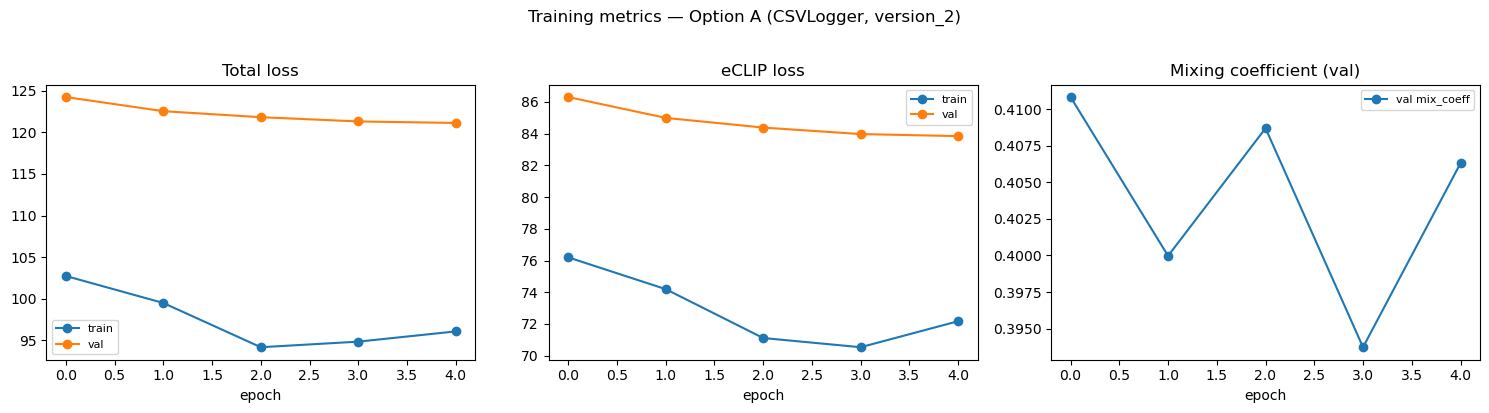

⏱ 0.20 s (00:00:00)


In [33]:
# Read metrics.csv from CSVLogger (persists across kernel restarts)
# Path: FILEPATHS["output_dir"] / "csv_logs" / version_N / metrics.csv
# Each training run creates a new version_N; the latest is used here.
import pandas as pd
import matplotlib.pyplot as plt

csv_log_dir = FILEPATHS["output_dir"] / "csv_logs"
metrics_paths = sorted(csv_log_dir.glob("version_*/metrics.csv"))
assert metrics_paths, f"No CSV log found under {csv_log_dir} — run training first."
df_csv = pd.read_csv(metrics_paths[-1])
logger.info(f"Reading metrics from: {metrics_paths[-1]}")
logger.info(f"Available keys: {[c for c in df_csv.columns if c not in ('step', 'epoch')]}")

# Collapse to one row per epoch: epoch-level metrics appear once per epoch (with NaN elsewhere)
epoch_df = df_csv.groupby("epoch").last().reset_index()

plots = [
    ({"train": "train/loss_epoch", "val": "val/loss"}, "Total loss"),
    ({"train": "train/loss_eCLIP_epoch", "val": "val/loss_eCLIP"}, "eCLIP loss"),
    ({"val mix_coeff": "val/mix_coeff"}, "Mixing coefficient (val)"),
]

fig, axes = plt.subplots(1, len(plots), figsize=(15, 4))
for (col_dict, title), ax in zip(plots, axes):
    for label, col in col_dict.items():
        if col in epoch_df.columns:
            epoch_df.plot("epoch", col, ax=ax, label=label, marker="o")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle(f"Training metrics — Option A (CSVLogger, {metrics_paths[-1].parent.name})", y=1.02)
plt.tight_layout()
plt.show()

### Eval on test set

Loading dataset from /home/l10n/projects/parnet-project/parnet--demo--train-models/results/spliceosome-hepg2/dataset.pt for split 'test'... /home/l10n/projects/parnet-project/parnet--demo--train-models/.pixi/envs/parnet-dev-cu11/lib/python3.10/site-packages/parnet/data/datasets.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True

RBP           Profile Pearson r   n sequences
---------------------------------------------
AQR                      0.1364         10193
BUD13                    0.1486         13879
EFTUD2                   0.1077         13123
PRPF8                    0.1595         12815
RBM22                    0.1397         14075
SF3B4                    0.1333          8028
SMNDC1                   0.0991         12118
U2AF1                    0.2104         15163
U2AF2                    0.1924         14959
---------------------------------------------
Mean                     0.1475


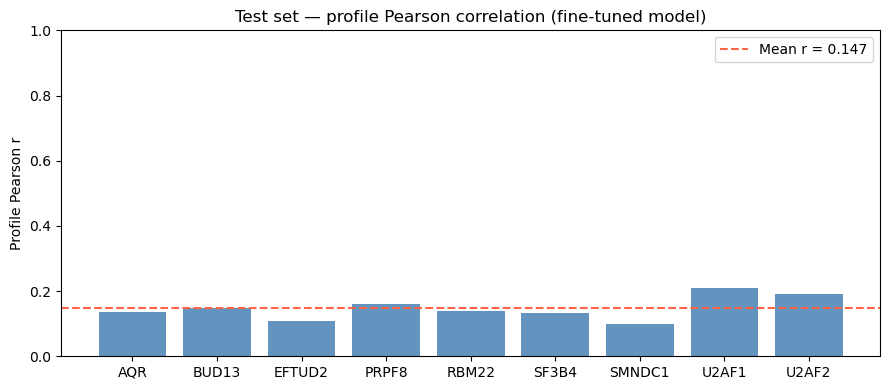

⏱ 147.77 s (00:02:27)


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Load test split ──────────────────────────────────────────────────────────
test_ds = ListDataset(
    FILEPATHS["filtered_dataset"], split="test", length=params_seq_length, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)
logger.info(f"Test set: {len(test_ds)} sequences")

# ── Collect predictions over the full test set ───────────────────────────────
model_reloaded.eval()
_pred_chunks, _tgt_chunks = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference"):
        seq = batch["inputs"]["sequence"].to(device)
        out = model_reloaded(seq)
        _pred_chunks.append(out["total"].cpu())  # log-prob (B, T, L)
        _tgt_chunks.append(batch["outputs"]["total"].float())  # counts   (B, T, L)

all_pred_logprob = torch.cat(_pred_chunks)  # (N, 9, 600)
all_targets_raw = torch.cat(_tgt_chunks)  # (N, 9, 600)
del _pred_chunks, _tgt_chunks

# ── Profile Pearson correlation per RBP ──────────────────────────────────────
# For each (sequence, RBP) pair with non-zero signal:
#   correlate softmax(predicted) vs normalised actual count profile.
# Vectorised over sequences per RBP to avoid per-sample Python loops.


def _batch_pearsonr(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Vectorised row-wise Pearson r. x, y: (N, L) → (N,)."""
    xm = x - x.mean(axis=1, keepdims=True)
    ym = y - y.mean(axis=1, keepdims=True)
    num = (xm * ym).sum(axis=1)
    denom = np.sqrt((xm**2).sum(axis=1) * (ym**2).sum(axis=1))
    return np.where(denom > 1e-10, num / denom, 0.0)


pred_prob = all_pred_logprob.exp()  # (N, 9, 600)
count_total = all_targets_raw.sum(-1, keepdim=True).clamp(min=1)  # (N, 9, 1)
target_prob = all_targets_raw / count_total  # (N, 9, 600)

rbp_cts = saved_meta["rbp_cts"]
rbp_names = [ct.replace("_HepG2", "") for ct in rbp_cts]

per_rbp_r = []
for task_i in range(len(rbp_cts)):
    has_signal = all_targets_raw[:, task_i, :].sum(-1) > 0
    if not has_signal.any():
        per_rbp_r.append(float("nan"))
        continue
    rs = _batch_pearsonr(
        pred_prob[has_signal, task_i, :].numpy(),
        target_prob[has_signal, task_i, :].numpy(),
    )
    per_rbp_r.append(float(np.nanmean(rs)))

mean_r = float(np.nanmean(per_rbp_r))

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'RBP':<12s}  {'Profile Pearson r':>17s}  {'n sequences':>12s}")
print("-" * 45)
for task_i, (name, r) in enumerate(zip(rbp_names, per_rbp_r)):
    n = int((all_targets_raw[:, task_i, :].sum(-1) > 0).sum())
    print(f"{name:<12s}  {r:>17.4f}  {n:>12d}")
print("-" * 45)
print(f"{'Mean':<12s}  {mean_r:>17.4f}")

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(rbp_names, per_rbp_r, color="steelblue", alpha=0.85)
ax.axhline(mean_r, color="tomato", linestyle="--", linewidth=1.5, label=f"Mean r = {mean_r:.3f}")
ax.set_ylabel("Profile Pearson r")
ax.set_title("Test set — profile Pearson correlation (fine-tuned model)")
ax.set_ylim(0, max(1.0, max(r for r in per_rbp_r if not np.isnan(r)) * 1.1))
ax.legend()
plt.tight_layout()
plt.show()

### Display example predictions

Picks the test sequence with the highest eCLIP signal for 3 selected RBPs and shows
three tracks per RBP:

| Row | Colour | What |
|---|---|---|
| Ground truth | blue | eCLIP read counts from the test set |
| Fine-tuned | orange | Predicted probability profile from the fine-tuned model |
| Pretrained | green | Predicted probability profile from the **original** pretrained model (full 223-task head) |

The pretrained model's output for each of the 9 RBPs is extracted by indexing
into its 223-task head using `track_indices_in_full_dataset` stored in the
dataset metadata, so the comparison is always aligned to the correct RBP.

[13:11:25] INFO - Selected test sequence #7077  (combined signal for ['PRPF8', 'U2AF2', 'AQR']: 2628 reads)
INFO:train_from_pretrained.py.ipynb:Selected test sequence #7077  (combined signal for ['PRPF8', 'U2AF2', 'AQR']: 2628 reads)


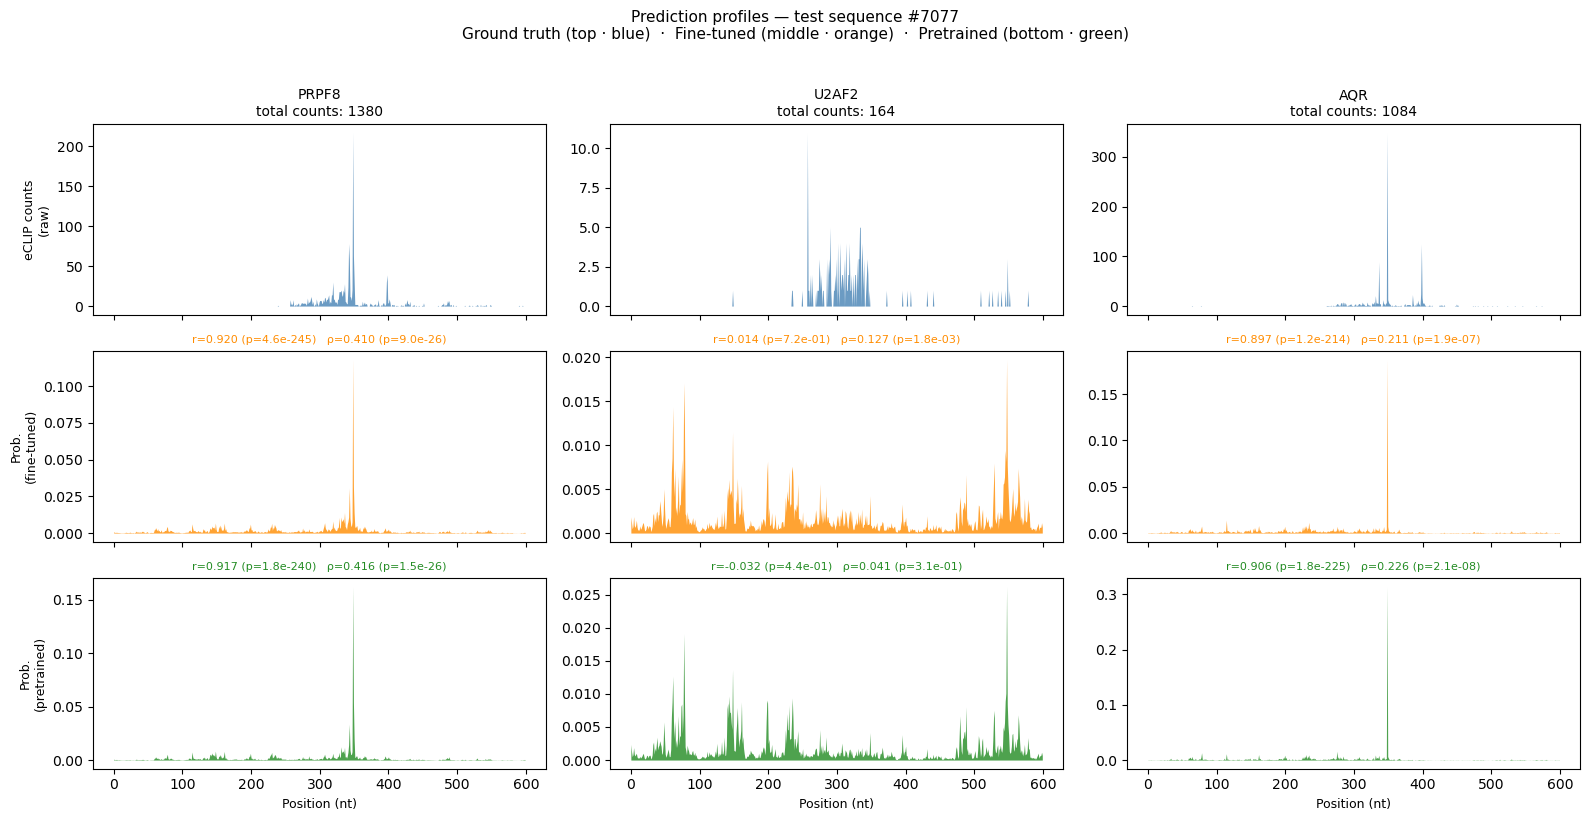

⏱ 0.77 s (00:00:00)


In [36]:
from scipy.stats import pearsonr, spearmanr

# ── Reload original pretrained model (unmodified 223-task head) ──────────────
# We must reload from disk because `model` was mutated in-place (head replaced +
# fine-tuned). This gives us the baseline: what the pretrained backbone + head
# predicts before any task-specific fine-tuning.
_model_pretrained = load_parnet_model(
    pretrained_model_name,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)
_model_pretrained.eval()

# ── Choose 3 RBPs to display ─────────────────────────────────────────────────
# Edit this list to compare different RBPs; names must match saved_meta["rbp_cts"]
# without the "_HepG2" suffix.
_show_names = ["PRPF8", "U2AF2", "AQR"]

# Indices into the 9-task fine-tuned model (order fixed by saved_meta["rbp_cts"]).
_show_ft_idx = [rbp_cts.index(f"{n}_HepG2") for n in _show_names]

# Corresponding task indices in the full 223-task pretrained head.
# Stored in dataset metadata by prepare_datasets so the mapping is always correct
# regardless of how the 9-task subset was chosen.
_pretrained_task_indices = saved_meta["track_indices_in_full_dataset"]
_show_pt_idx = [_pretrained_task_indices[i] for i in _show_ft_idx]

# ── Find the test sequence with the strongest combined signal ─────────────────
# We maximise the total raw eCLIP read count across the 3 chosen RBPs so the
# plot shows a biologically informative, signal-rich window rather than a
# low-count or background-dominated example.
_signal = all_targets_raw[:, _show_ft_idx, :].sum(dim=[-1, -2])
_seq_idx = int(_signal.argmax())
_gt_counts = all_targets_raw[_seq_idx]  # (9, 600) raw eCLIP read counts
logger.info(
    f"Selected test sequence #{_seq_idx}  "
    f"(combined signal for {_show_names}: {int(_signal[_seq_idx])} reads)"
)

# ── Run both models on the selected sequence ──────────────────────────────────
_seq_tensor = test_ds[_seq_idx]["inputs"]["sequence"].float().unsqueeze(0).to(device)

with torch.no_grad():
    _out_ft = model_reloaded(_seq_tensor)  # fine-tuned  → (1,   9, 600)
    _out_pt = _model_pretrained(_seq_tensor)  # pretrained  → (1, 223, 600)

_prob_ft = _out_ft["total"][0].cpu().exp()  # (9,   600) softmax probabilities
_prob_pt = _out_pt["total"][0].cpu().exp()  # (223, 600) softmax probabilities

# ── Plot 3-row × 3-column grid ────────────────────────────────────────────────
_pos = np.arange(params_seq_length)

fig, axes = plt.subplots(3, len(_show_names), figsize=(16, 8), sharex=True)
fig.suptitle(
    f"Prediction profiles — test sequence #{_seq_idx}\n"
    "Ground truth (top · blue)  ·  Fine-tuned (middle · orange)  ·  Pretrained (bottom · green)",
    y=1.02,
    fontsize=11,
)

_kw = dict(linewidth=0)
for col, (name, fi, pi) in enumerate(zip(_show_names, _show_ft_idx, _show_pt_idx)):
    gt_raw = _gt_counts[fi].numpy()  # raw eCLIP read counts (integer, not normalised)
    pf = _prob_ft[fi].numpy()  # fine-tuned probability profile
    pp = _prob_pt[pi].numpy()  # pretrained probability profile

    # Pearson r: invariant to linear scaling, so comparing probabilities against
    # raw counts gives the same value as against normalised counts.
    # Spearman ρ: rank-based, also unaffected by normalisation.
    # Both are computed against raw counts for transparency.
    r_ft, p_ft = pearsonr(pf, gt_raw)
    rho_ft, sp_ft = spearmanr(pf, gt_raw)
    r_pt, p_pt = pearsonr(pp, gt_raw)
    rho_pt, sp_pt = spearmanr(pp, gt_raw)

    # Row 0: raw eCLIP read counts; title shows total count for this RBP on this window
    axes[0, col].fill_between(_pos, gt_raw, alpha=0.80, color="steelblue", **_kw)
    axes[0, col].set_title(f"{name}\ntotal counts: {int(gt_raw.sum())}", fontsize=10)

    # Row 1: fine-tuned prediction; title quantifies agreement with ground truth
    axes[1, col].fill_between(_pos, pf, alpha=0.80, color="darkorange", **_kw)
    axes[1, col].set_title(
        f"r={r_ft:.3f} (p={p_ft:.1e})   ρ={rho_ft:.3f} (p={sp_ft:.1e})",
        fontsize=8,
        color="darkorange",
    )

    # Row 2: pretrained prediction; same metrics for direct comparison
    axes[2, col].fill_between(_pos, pp, alpha=0.80, color="forestgreen", **_kw)
    axes[2, col].set_title(
        f"r={r_pt:.3f} (p={p_pt:.1e})   ρ={rho_pt:.3f} (p={sp_pt:.1e})",
        fontsize=8,
        color="forestgreen",
    )
    axes[2, col].set_xlabel("Position (nt)", fontsize=9)

axes[0, 0].set_ylabel("eCLIP counts\n(raw)", fontsize=9)
axes[1, 0].set_ylabel("Prob.\n(fine-tuned)", fontsize=9)
axes[2, 0].set_ylabel("Prob.\n(pretrained)", fontsize=9)

plt.tight_layout()
plt.show()

# Free GPU memory: pretrained model only needed for this comparison cell
del _model_pretrained